In [155]:
import numpy as np
import matplotlib.pyplot as plt

In [156]:
# def downscale_grayscale(image, factor):
#     h, w = image.shape

#     new_h = h // factor
#     new_w = w // factor

#     small = np.zeros((new_h, new_w))

#     for i in range(new_h):
#         for j in range(new_w):
#             block = image[i*factor:(i+1)*factor, j*factor:(j+1)*factor]
#             small[i, j] = block.mean()

#     return small

def downscale_grayscale(img, factor):
    h, w = img.shape
    new_h = h // factor
    new_w = w // factor

    out = np.zeros((new_h, new_w), dtype=img.dtype)

    kernel = np.ones((factor, factor)) / (factor**2)

    for i in range(new_h):
        for j in range(new_w):
            block = img[i*factor:(i+1)*factor, j*factor:(j+1)*factor]
            out[i, j] = np.sum(block * kernel)

    return out


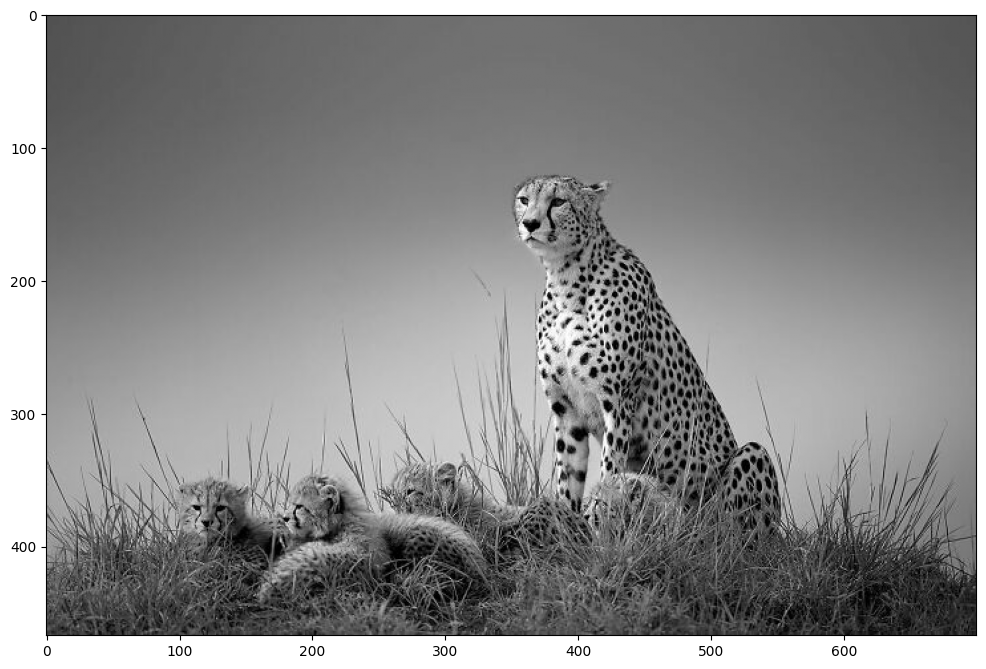

In [157]:

img = plt.imread('zdjecie.jpg')

plt.figure(figsize=(12, 12))
plt.imshow(img, cmap='gray')
plt.show()

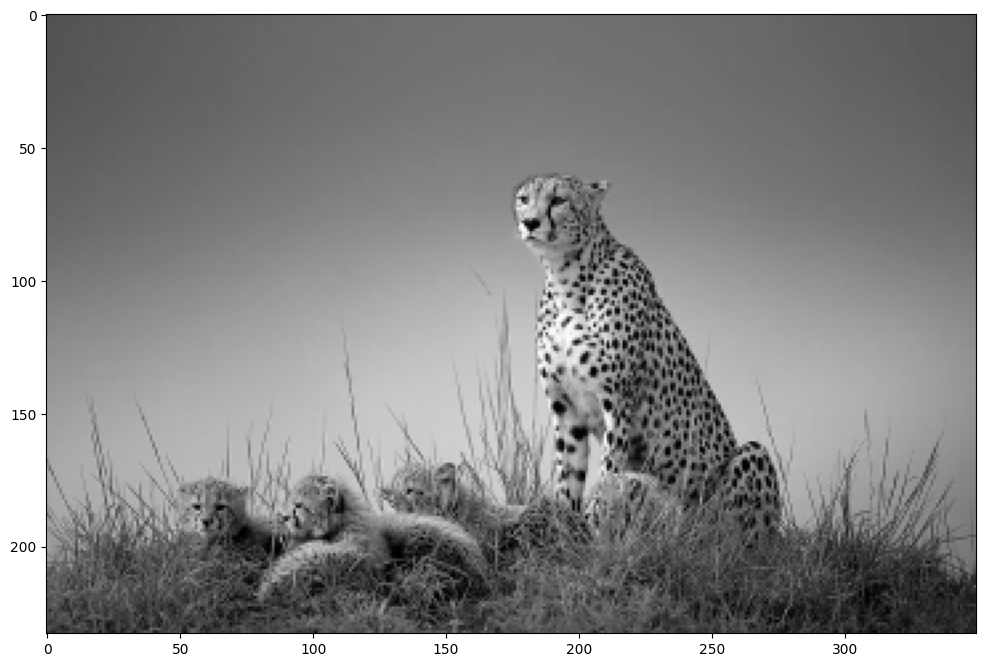

In [158]:
small = downscale_grayscale(img, 2)

plt.figure(figsize=(12, 12))
plt.imshow(small, cmap='gray')
plt.show()

In [159]:
def convolve_1d(signal, kernel):
    m = len(kernel)
    r = m // 2
    n = len(signal)

    out = np.zeros(n)

    for i in range(n):
        s = 0.0
        for k in range(m):
            idx = i + k - r
            if 0 <= idx < n:
                s += signal[idx] * kernel[k]
        out[i] = s

    return out

In [160]:
def interpolate_1d(signal, scale, kernel_fn):
    n = len(signal)
    new_n = int(np.round(n * scale))

    out = np.zeros(new_n)

    for i in range(new_n):
        x = i / scale
        left = int(np.floor(x))
        right = min(left + 1, n - 1)
        t = x - left
        out[i] = (1 - t) * signal[left] + t * signal[right]

    t_vals = np.linspace(-1, 1, 21)
    kernel = kernel_fn(t_vals)

    if kernel.sum() != 0:
        kernel = kernel / kernel.sum()

    return convolve_1d(out, kernel)


In [161]:
def upscale_grayscale(image, scale, kernel_fn):
    h, w = image.shape

    temp = np.zeros((h, w * scale))
    for i in range(h):
        temp[i] = interpolate_1d(image[i], scale, kernel_fn)

    new_h = h * scale
    result = np.zeros((new_h, w * scale))
    for j in range(temp.shape[1]):
        result[:, j] = interpolate_1d(temp[:, j], scale, kernel_fn)

    return result

In [162]:
def h1(t):
    return np.where((t >= 0) & (t < 1), 1, 0)


def h2(t):
    return np.where((t >= -1/2) & (t < 1/2), 1, 0)


def h3(t):
    return np.where((t >= -1) & (t <= 1), 1 - abs(t), 0)


def h4(t):
    return np.sinc(t / np.pi)  # https://numpy.org/doc/stable/reference/generated/numpy.sinc.html#numpy.sinc

kernels = [h1, h2, h3, h4]

In [163]:
def MSE(y, y_interp):
  return np.mean((y - y_interp) ** 2)

(467, 700) (466, 700)
h1 MSE:  668.6283517460147
(467, 700) (466, 700)
h2 MSE:  487.8625073116377
(467, 700) (466, 700)
h3 MSE:  506.3543381193683
(467, 700) (466, 700)
h4 MSE:  583.7250585012591


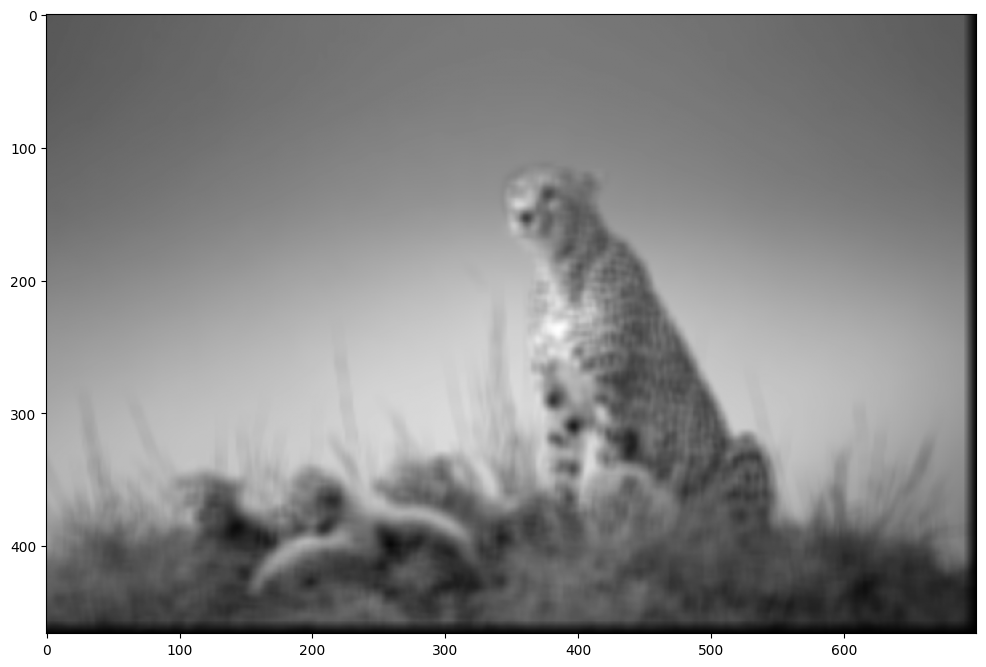

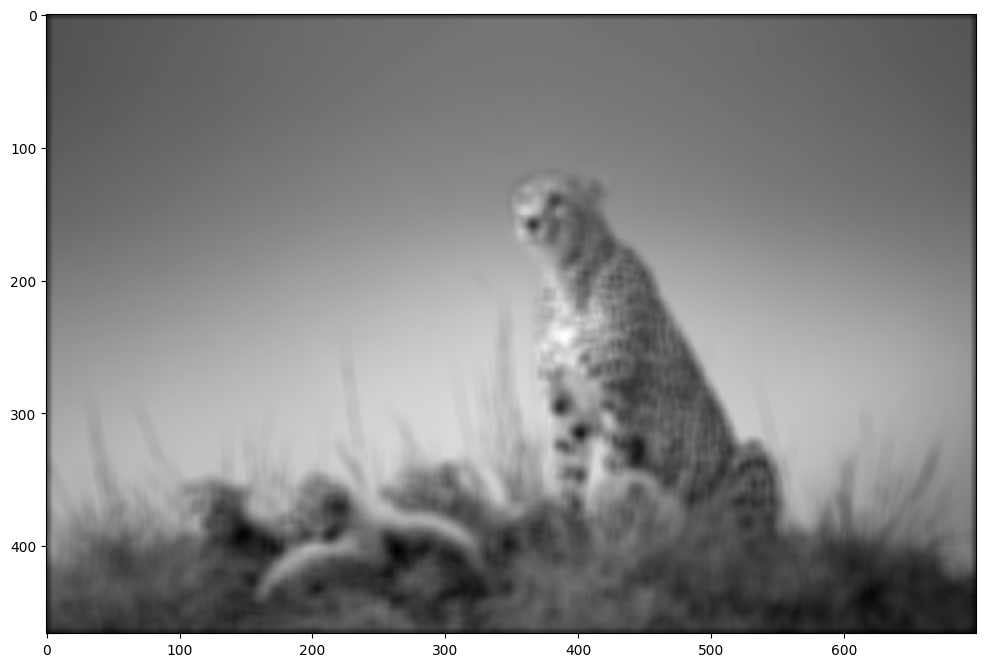

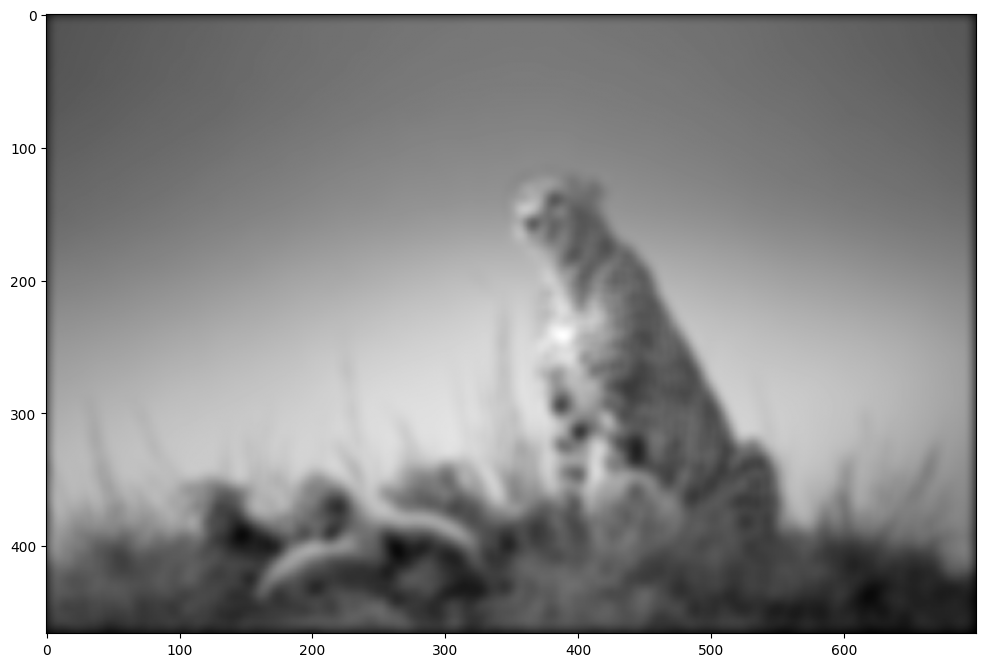

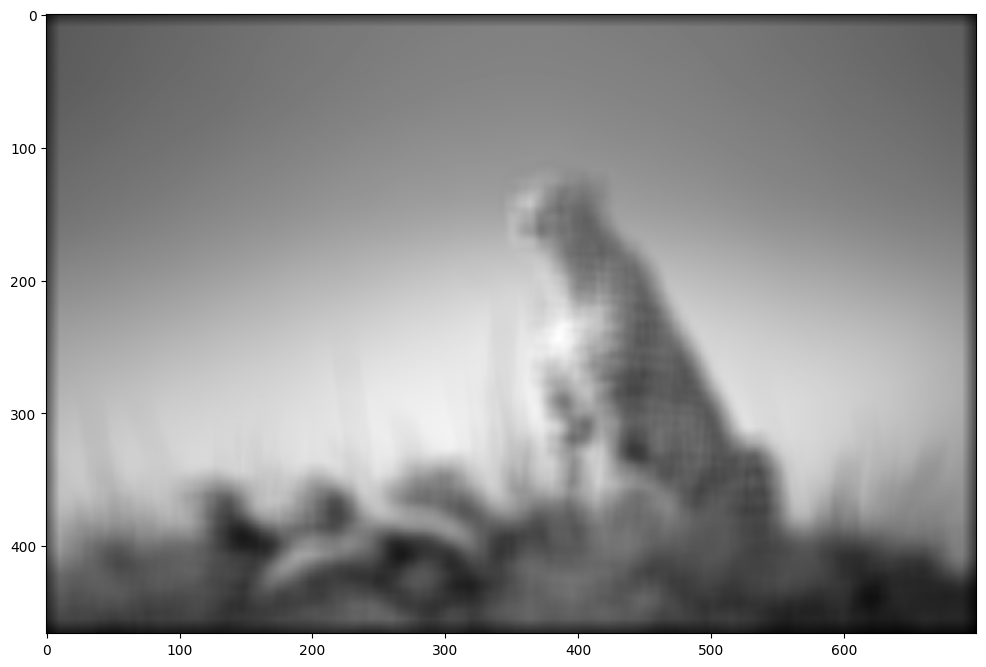

In [164]:
for kernel in kernels:
  big = upscale_grayscale(small, 2, kernel)

  plt.figure(figsize=(12, 12))
  plt.imshow(big, cmap='gray')
  print(img.shape, big.shape)
  h = min(img.shape[0], big.shape[0])
  w = min(img.shape[1], big.shape[1])

  img_c = img[:h, :w]
  big_c = big[:h, :w]

  print(f"{kernel.__name__} MSE: ", MSE(img_c, big_c))

plt.show()

In [165]:
def downscale_maxpool_2d(img, scale):
    h, w = img.shape[:2]
    new_h = max(int(np.round(h * scale)), 1)
    new_w = max(int(np.round(w * scale)), 1)

    row_scale = h / new_h
    col_scale = w / new_w

    if img.ndim == 2:
        out = np.zeros((new_h, new_w), dtype=img.dtype)
    else:
        channels = img.shape[2]
        out = np.zeros((new_h, new_w, channels), dtype=img.dtype)

    for i in range(new_h):
        for j in range(new_w):
            r_start = int(np.floor(i * row_scale))
            r_end   = int(np.floor((i+1) * row_scale))
            c_start = int(np.floor(j * col_scale))
            c_end   = int(np.floor((j+1) * col_scale))

            r_end = max(r_end, r_start + 1)
            c_end = max(c_end, c_start + 1)

            block = img[r_start:r_end, c_start:c_end]

            if img.ndim == 2:
                out[i, j] = np.max(block)
            else:
                out[i, j, :] = np.max(block, axis=(0,1))
    return out


In [172]:
def upscale_nearest(img, scale):
    if img.ndim == 2:
        h, w = img.shape
        channels = 1
    elif img.ndim == 3:
        h, w, channels = img.shape
    else:
        raise ValueError()

    new_h = int(np.round(h * scale))
    new_w = int(np.round(w * scale))

    row_idx = (np.arange(new_h) / scale).astype(int)
    col_idx = (np.arange(new_w) / scale).astype(int)

    if channels == 1:
        out = img[row_idx[:, None], col_idx]
    else:
        out = img[row_idx[:, None], col_idx, :]

    return out


(467, 700) (466, 700)
MSE:  29.436879215205394


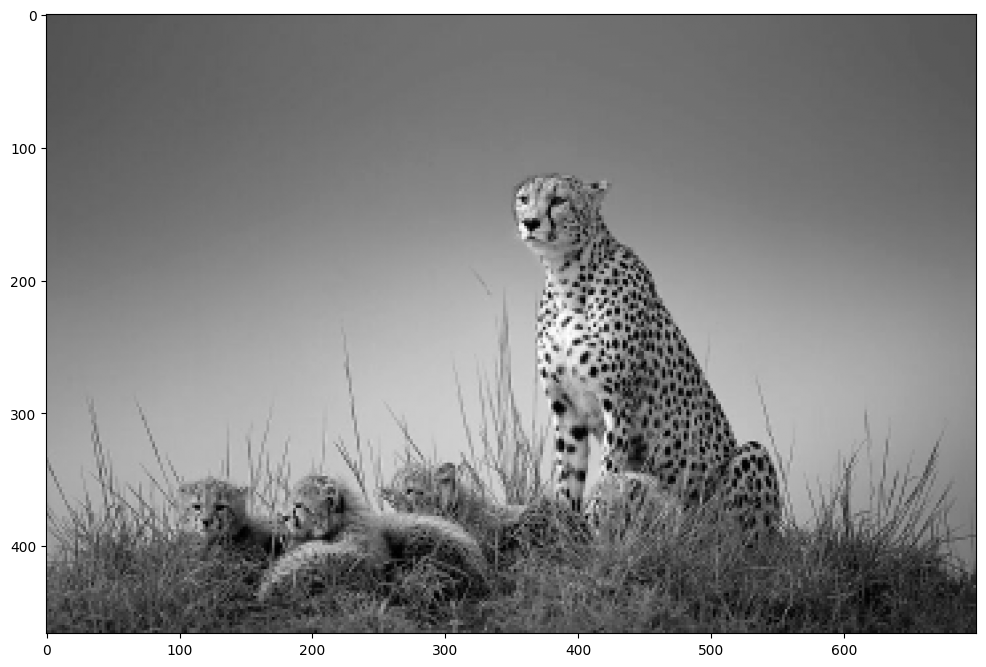

In [173]:
big = upscale_nearest(small, 2)

plt.figure(figsize=(12, 12))
plt.imshow(big, cmap='gray')
print(img.shape, big.shape)
h = min(img.shape[0], big.shape[0])
w = min(img.shape[1], big.shape[1])

img_c = img[:h, :w]
big_c = big[:h, :w]

print(f"MSE: ", MSE(img_c, big_c))

plt.show()

MSE:  30.97465891710003


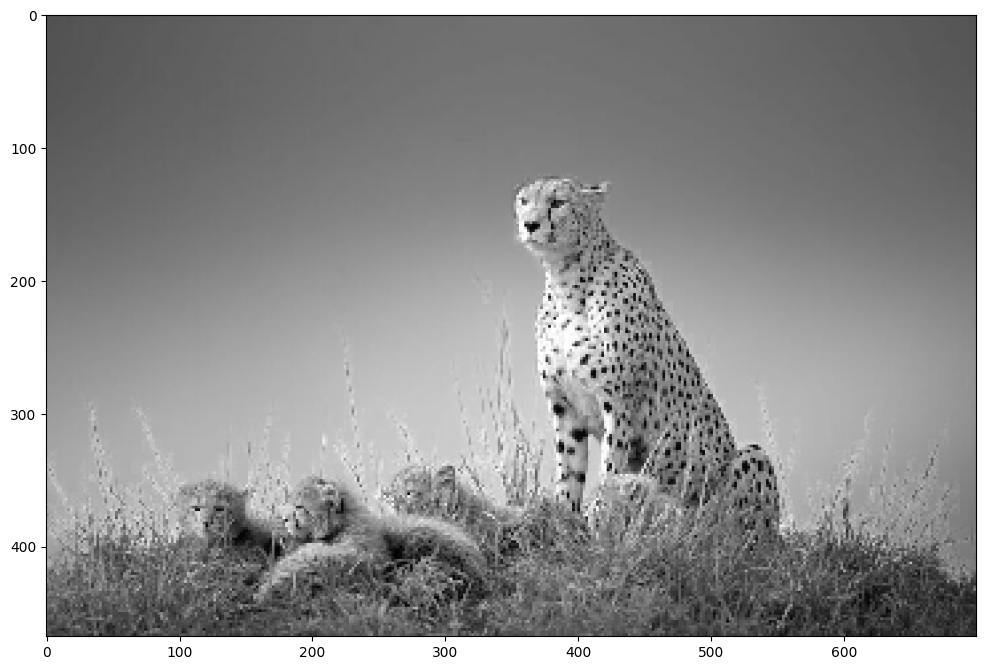

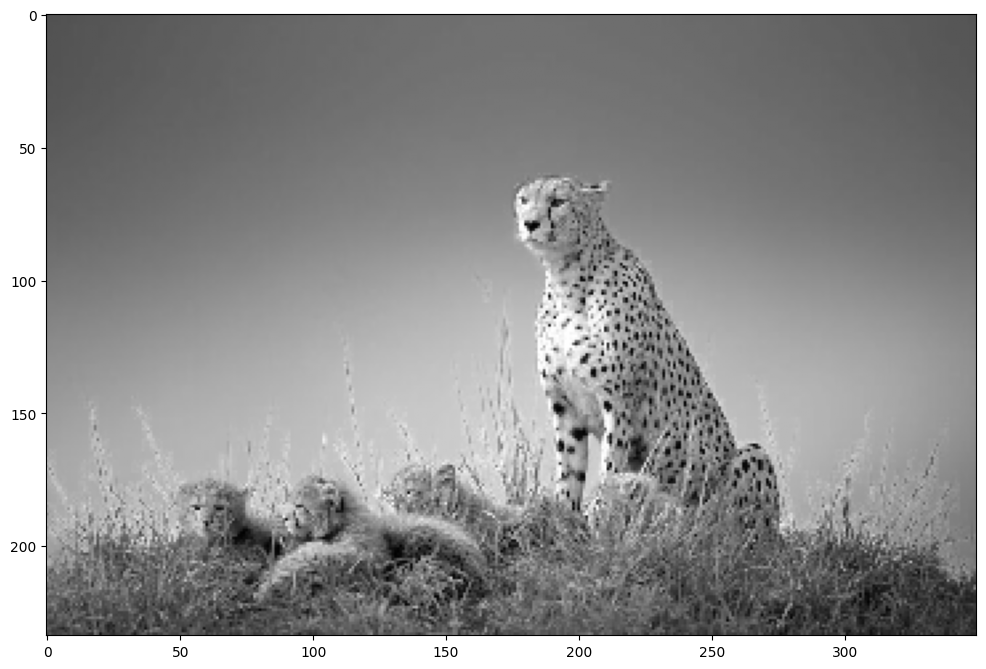

In [175]:
small_2 = downscale_maxpool_2d(img, 0.5)
big_2 = upscale_nearest(small_2, 2)

h = min(img.shape[0], big_2.shape[0])
w = min(img.shape[1], big_2.shape[1])

img_c = img[:h, :w]
resized = big_2[:h, :w]
mse = MSE(img_c, resized)

plt.figure(figsize=(12, 12))
plt.imshow(big_2, cmap='gray')

plt.figure(figsize=(12, 12))
plt.imshow(small_2, cmap='gray')


print("MSE: ", mse)
plt.show()

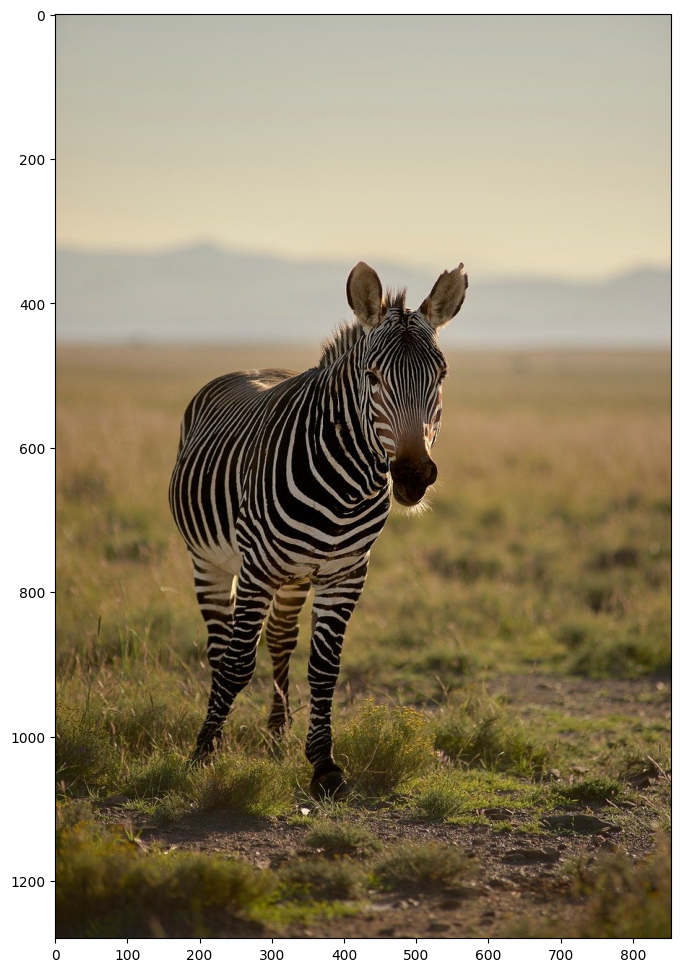

In [174]:
zebra_img = plt.imread('zebra.png')

plt.figure(figsize=(12, 12))
plt.imshow(zebra_img, cmap='gray')
plt.show()

MSE:  0.06588021694394207


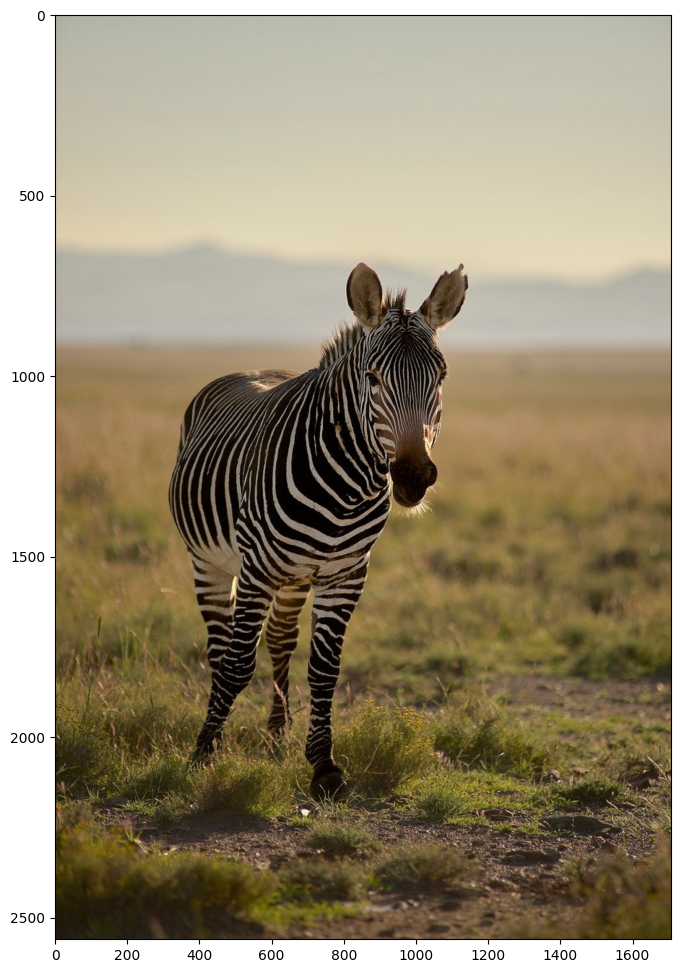

In [180]:
small_2 = downscale_maxpool_2d(zebra_img, 0.5)
big_2 = upscale_nearest(zebra_img, 2)

plt.figure(figsize=(12, 12))

h = min(zebra_img.shape[0], big_2.shape[0])
w = min(zebra_img.shape[1], big_2.shape[1])

img_c = zebra_img[:h, :w]
resized = big_2[:h, :w]
mse = MSE(img_c, resized)

plt.imshow(big_2)
print("MSE: ", mse)

plt.show()

MSE:  0.012184953
MSE2:  0.012184953
MSE3:  0.04522232
MSE4:  0.026263982


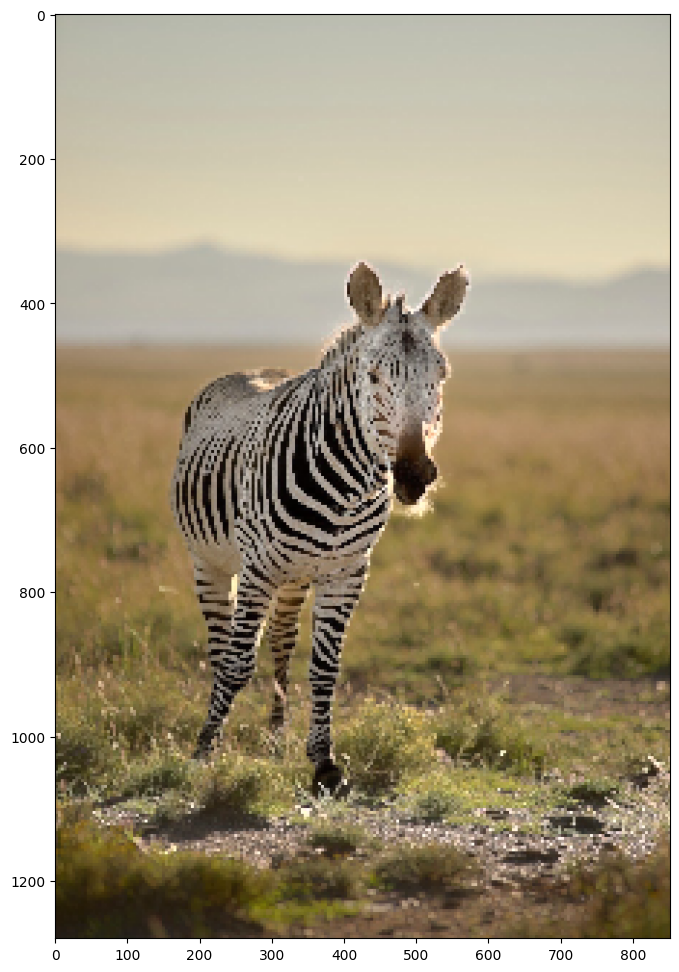

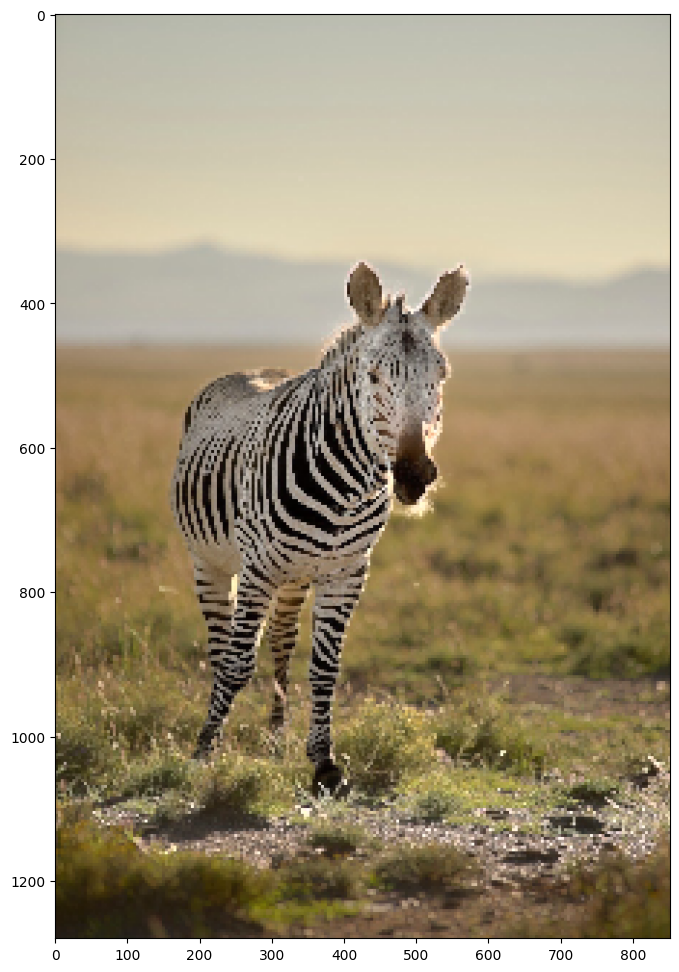

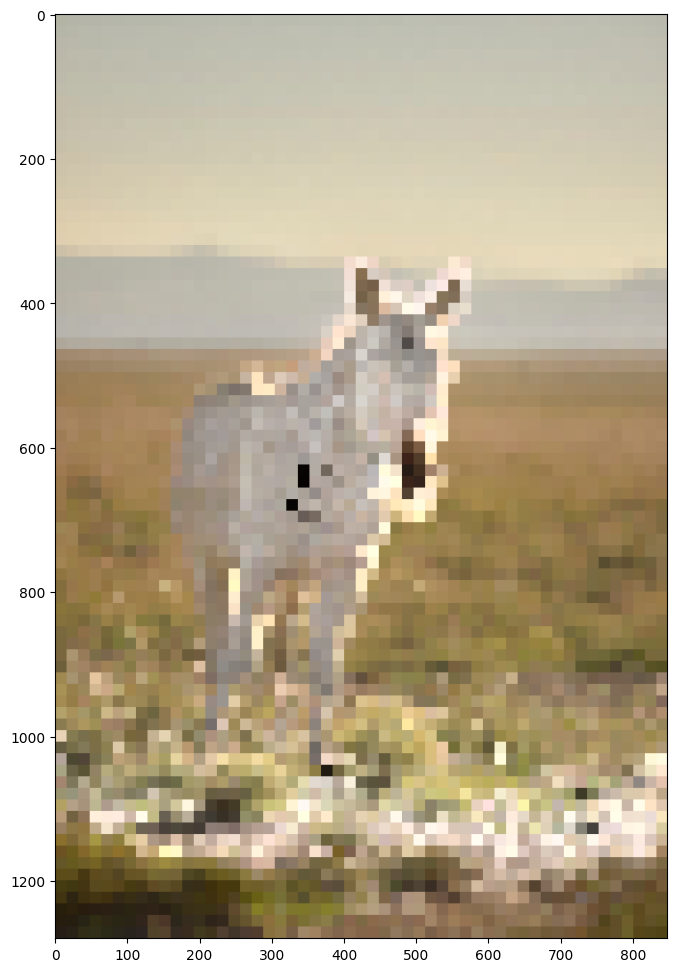

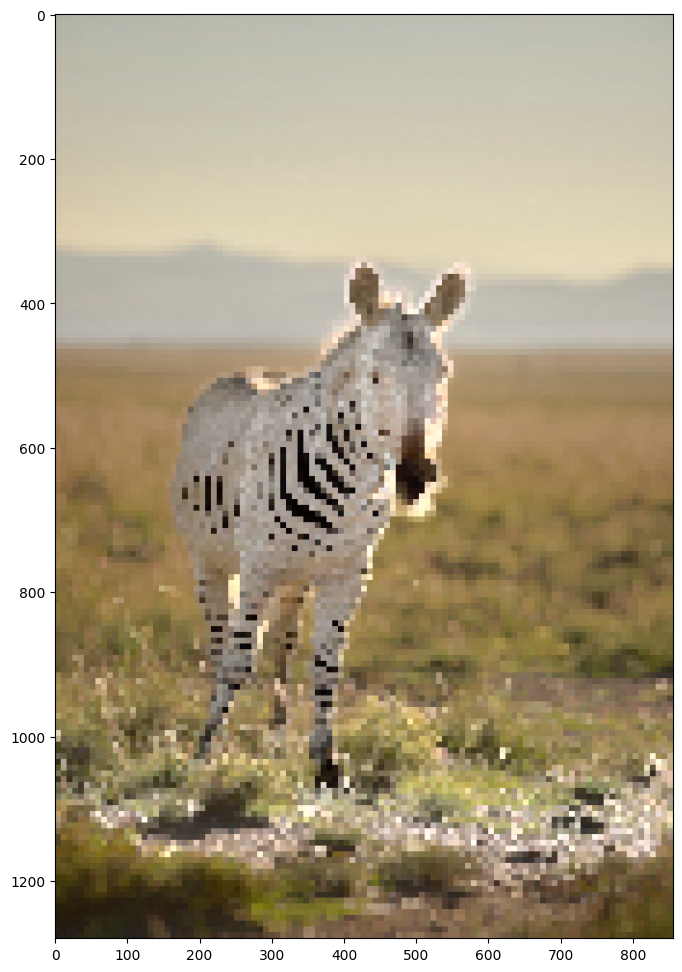

In [184]:
scaled_zebra = zebra_img

for _ in range(2):
  scaled_zebra = downscale_maxpool_2d(scaled_zebra, 0.5)

for _ in range(2):
  scaled_zebra = upscale_nearest(scaled_zebra, 2)

h = min(zebra_img.shape[0], scaled_zebra.shape[0])
w = min(zebra_img.shape[1], scaled_zebra.shape[1])

img_c = zebra_img[:h, :w]
scaled = scaled_zebra[:h, :w]

mse = MSE(img_c, scaled)
print("MSE: ", mse)

plt.figure(figsize=(12, 12))
plt.imshow(scaled_zebra)

scaled_zebra2 = upscale_nearest(downscale_maxpool_2d(zebra_img, 0.25), 4)
h2 = min(zebra_img.shape[0], scaled_zebra2.shape[0])
w2 = min(zebra_img.shape[1], scaled_zebra2.shape[1])

mse2 = MSE(zebra_img[:h2, :w2], scaled_zebra2[:h2, :w2])
print("MSE2: ", mse2)

plt.figure(figsize=(12, 12))
plt.imshow(scaled_zebra2)

scaled_zebra = zebra_img

for _ in range(4):
  scaled_zebra = downscale_maxpool_2d(scaled_zebra, 0.5)

for _ in range(4):
  scaled_zebra = upscale_nearest(scaled_zebra, 2)

h = min(zebra_img.shape[0], scaled_zebra.shape[0])
w = min(zebra_img.shape[1], scaled_zebra.shape[1])

img_c = zebra_img[:h, :w]
scaled = scaled_zebra[:h, :w]

mse3 = MSE(img_c, scaled)
print("MSE3: ", mse3)

plt.figure(figsize=(12, 12))
plt.imshow(scaled_zebra)

scaled_zebra2 = upscale_nearest(downscale_maxpool_2d(zebra_img, 0.125), 8)
h2 = min(zebra_img.shape[0], scaled_zebra2.shape[0])
w2 = min(zebra_img.shape[1], scaled_zebra2.shape[1])

mse4 = MSE(zebra_img[:h2, :w2], scaled_zebra2[:h2, :w2])
print("MSE4: ", mse4)

plt.figure(figsize=(12, 12))
plt.imshow(scaled_zebra2)

plt.show()
